# Neural Style Transfer

Neural Style Transfer is one of the first applications of neural networks to image generation.

It has been first proposed in 2016 by Gatys et al. in their paper [Image Style Transfer Using Convolutional Neural Networks](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf).

The goal is to render a photograph representing a given content, with the style specified by a different image. A typical example is the following:

![Example](https://docs.pytorch.org/tutorials/_images/neuralstyle.png)

The method is based on matching the features extracted by a convolutional neural network pretrained for image recognition.  As done in the original paper, the VGG-19 CNN is used.

Before addressing style transfer, there is a review of how VGG classifies images.

In [3]:
# Import the basic libraries.
import torch
import torchvision
import matplotlib.pyplot as plt

### Neural network

Model: VGG-19 convolutional network ([Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556) by Symonian and Zisserman, 2014).

The structure of the this CNN is quite simple, and includes convolutions, the ReLU activation function, max pooling layers, and a couple of fully-connected layers. The convolutional section acts as a feature extractor, and the final layers perform a classification.

![VGG schema](https://www.researchgate.net/publication/325137356/figure/fig2/AS:670371271413777@1536840374533/llustration-of-the-network-architecture-of-VGG-19-model-conv-means-convolution-FC-means.jpg)

`torchvision` is a Pytorch extra library providing models, tools, and datasets for computer vision applications. It includes a definition of the VGG-19 network, and makes available weights pretrained on 1000 categories of the ImageNet dataset.


In [4]:
weights = torchvision.models.VGG19_Weights.IMAGENET1K_V1
net = torchvision.models.vgg19(weights=weights)
preprocess = weights.transforms() # how we get preprocessing for these models

print(net)
ps = sum(param.numel() for param in net.parameters())
print(f"{ps:,d} parameters")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 78.2MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

### Test the network

Let's test the network on an image downloaded from the Internet. VGG has been trained on $224\times 224$ RGB images.

torch.float32 torch.Size([1, 3, 224, 224])


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

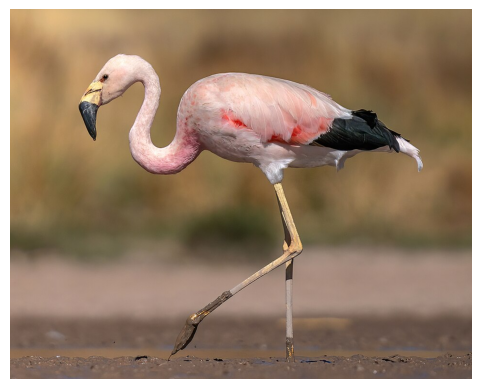

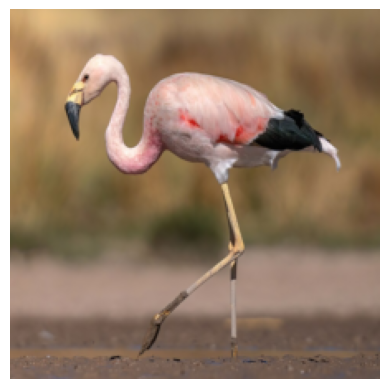

In [5]:
import torchvision.transforms.functional as TF

URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Andean_Flamingo%2C_Salta%2C_AR_imported_from_iNaturalist_photo_171995487_%28cropped%29.jpg/960px-Andean_Flamingo%2C_Salta%2C_AR_imported_from_iNaturalist_photo_171995487_%28cropped%29.jpg"
!wget -q -O img.jpg $URL

# Resize and show the image...

photo = plt.imread("img.jpg") # it is a numpy array
plt.imshow(photo)
plt.axis("off")

im = TF.to_tensor(photo) # also transforms dtype from ints to floating points
im = TF.resize(im, (224, 224)).unsqueeze(0)
print(im.dtype, im.shape)

plt.figure()
plt.imshow(im.squeeze(0).permute(1, 2, 0))
plt.axis("off")

Use the network to find the probability estimates for the 1000 classes. Print the values for the top five predictions.

In [ ]:
# Use the network to classify the image.
net.eval()
imagenet_classes = torchvision.models.vgg._IMAGENET_CATEGORIES

scores = net(im)
probs = torch.softmax(scores, 1)
indices = probs.topk(5).indices.squeeze(0)
for cl in indices:
  print(f"{imagenet_classes[cl]:10}: {100*probs[0, cl]:2f}%")

American egret: 55.244553%
spoonbill : 37.111092%
flamingo  : 4.804256%
crane bird: 2.304453%
little blue heron: 0.334139%


### Preprocessing

During training, images have been preprocessed. Besides resizing them to $224 \times 224$, each color channel has been normalized by subtracting the mean and dividing by the standard deviation. Preprocessing is available as `weights.transforms()`.  

flamingo  : 88.561760%
spoonbill : 6.543160%
crane bird: 3.485950%
American egret: 1.200843%
little blue heron: 0.101292%


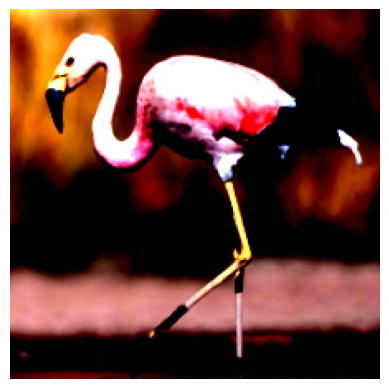

In [7]:
# net.train() # common mistake, in train mode the dropout is applied to the classification, is not as accurate
net.eval()
preprocess = weights.transforms()
preprocessed = preprocess(im)

plt.imshow(preprocessed.squeeze(0).permute(1, 2, 0))
plt.axis("off")

# Use the network to classify the image.
# Then print the class names and probability estimates for the the top five predictions...

scores = net(preprocessed)
probs = torch.softmax(scores, 1)
indices = probs.topk(5).indices.squeeze(0)
for cl in indices:
  print(f"{imagenet_classes[cl]:10}: {100*probs[0, cl]:2f}%")

## Style transfer

In style transfer an image is generated to show the same content of a given *content image*, but rendered with the style of a given *style image*.

The new image is obtained by matching its features, computed by the CNN, to those of the two references.

Usually, with neural networks, backpropagation and optimization algorithms are used to find the best parameters to solve the given task.  Here, they are used to find the best input.

Let's start by downloading the content and the style images.

Content image: torch.Size([1, 3, 256, 256])
Style image: torch.Size([1, 3, 256, 256])


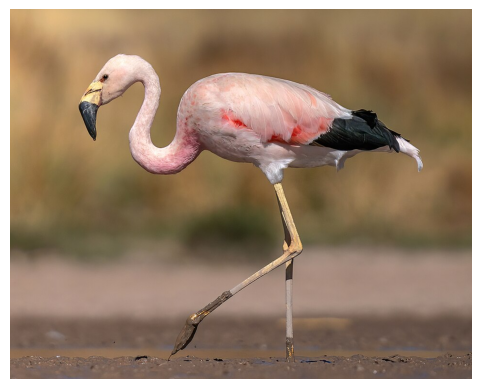

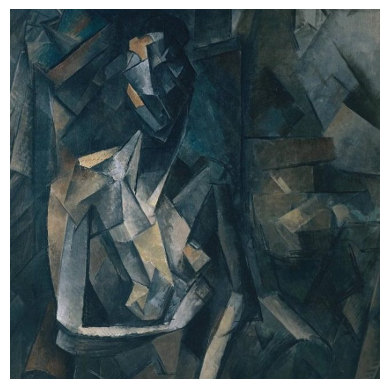

In [8]:
CONTENT_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Andean_Flamingo%2C_Salta%2C_AR_imported_from_iNaturalist_photo_171995487_%28cropped%29.jpg/960px-Andean_Flamingo%2C_Salta%2C_AR_imported_from_iNaturalist_photo_171995487_%28cropped%29.jpg"
# CONTENT_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/View_of_Mount_Fuji_from_%C5%8Cwakudani_20211202.jpg/330px-View_of_Mount_Fuji_from_%C5%8Cwakudani_20211202.jpg"
# CONTENT_URL = "https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"
# CONTENT_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/8/85/John_Lennon_%22Walls_and_Bridges%22_1974_press_photo_2_%28color%29_%28cropped%29.jpg/500px-John_Lennon_%22Walls_and_Bridges%22_1974_press_photo_2_%28color%29_%28cropped%29.jpg"
!wget -q -O content.jpg $CONTENT_URL
content_photo = plt.imread("content.jpg")
plt.imshow(content_photo)
plt.axis("off")

STYLE_URL = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
# STYLE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Tsunami_by_hokusai_19th_century.jpg/960px-Tsunami_by_hokusai_19th_century.jpg"
# STYLE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg/500px-Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg"
# STYLE_URL = "https://i0.wp.com/blog.artsper.com/wp-content/uploads/2013/06/crying-girl.jpg?w=1024&ssl=1"
!wget -q -O style.jpg $STYLE_URL
style_photo = plt.imread("style.jpg")
plt.figure()
plt.imshow(style_photo)
plt.axis("off")

WIDTH = 256
HEIGHT = 256

content_img = TF.to_tensor(content_photo)
content_img = TF.resize(content_img, (HEIGHT, WIDTH))
content_img = content_img.unsqueeze(0)
style_img = TF.to_tensor(style_photo)
style_img = TF.resize(style_img, (HEIGHT, WIDTH))
style_img = style_img.unsqueeze(0)

print(f"Content image: {content_img.shape}")
print(f"Style image: {style_img.shape}")

### GPU

Style transfer requires heavy computation. Better use a GPU.

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(DEVICE)
style_img = style_img.to(DEVICE)
content_img = content_img.to(DEVICE)
print("Device: ", DEVICE)

Device:  cuda


## Feature extraction

Different layers capture different features of the images. The first layers encode simple features (color, lines...), while deeper layers encode more abstract patterns.

Neural style transfer use activations by intermediate layers as features.
For the content, a single layer is used (`conv2_2` in the VGG diagram).
For the style, five layers are used (`conv1_1`, `conv2_1`, `conv3_1`, `conv4_1`, `conv5_1`).

Our network is includes three modules: `features`, `avgpool`, and `classifier`.  All the layers we interested in are in the first module, which is defined as a `torch.nn.Sequential`.  This means that we can compute the activations of layer `k` with `net.features[:(k + 1)](x)`.

For the style layers, features are used to compute a Gram Matrix:

$$ G = \frac{1}{H\times W} F F^T,$$

where $F$ is the $C \times (HW)$ matrix of the activations.

In [ ]:
CONTENT_LAYERS = [22]
STYLE_LAYERS = [1, 6, 11, 20, 29]

# Compute the gram matrix of the features
def gram_matrix(x):
  b, c, h, w = x.shape
  f = x.view(c, h * w) # assume to have batch of 1, otherwise f = x.view(b, c, h * w)
  G = (f @ (f.T)) / (h*w)
  return G

def extract_features(x):
    content_features = []
    style_features = []
    start = 0
    for layer in sorted(CONTENT_LAYERS + STYLE_LAYERS):
      x = net.features[start:(layer + 1)](x)
      if layer in CONTENT_LAYERS:
        content_features.append(x)
      elif layer in STYLE_LAYERS:
        style_features.append(gram_matrix(x))
      start = layer + 1
    return content_features + style_features


# Compute the features for the normalized style and content images
MEAN = preprocess.mean
STD = preprocess.std

with torch.no_grad():
    content_features = extract_features(TF.normalize(content_img, MEAN, STD))
    style_features = extract_features(TF.normalize(style_img, MEAN, STD))

# The network expects a normalised image
print("CONTENT IMAGE")
for f in content_features:
    print(f.shape)
print("STYLE IMAGE")
for f in style_features:
    print(f.shape)

CONTENT IMAGE
torch.Size([1, 512, 32, 32])
torch.Size([64, 64])
torch.Size([128, 128])
torch.Size([256, 256])
torch.Size([512, 512])
torch.Size([512, 512])
STYLE IMAGE
torch.Size([1, 512, 32, 32])
torch.Size([64, 64])
torch.Size([128, 128])
torch.Size([256, 256])
torch.Size([512, 512])
torch.Size([512, 512])


### Loss functions

Neural style transfer looks for the imager $x$ minimizing the following loss function:

$\mathcal{L}(x) = w_C \mathcal{L}_\text{content}(x) + w_S \mathcal{L}_\text{style}(x),$

where $w_C$ and $w_S$ are coefficients balancing the two components.

The *content loss* is just the mean squared error between the features of $x$ and those of the content image.

$$\mathcal{L}_\text{content}(x) = \frac{1}{C \times H \times W} \| F_x - F_\text{content}\|^2.$$

The *style loss* compares the Gram Matrices:

$$\mathcal{L}_\text{style}(x) = \sum_{l=1}^{5} \frac{1}{C_l^2} \|G^{(l)}_x - G^{(l)}_\text{style}\|_F^2,$$

where $\| \cdot \|_F^2$ is the squared Frobenius norm, that is just the sum of the squares of the elements of the difference.

In [ ]:
STYLE_WEIGHT = 1e5
CONTENT_WEIGHT = 1

def loss_fun(input_features, content_features, style_features):
    loss = 0.0
    k = len(CONTENT_LAYERS)
    for fi, fc in zip(input_features[:k], content_features[:k]):
        loss += CONTENT_WEIGHT * ((fi - fc) ** 2).mean()

    for gi, gc in zip(input_features[k:], style_features[k:]):
        loss += STYLE_WEIGHT * ((gi - gc) ** 2).mean()

    return loss


print(loss_fun(content_features, content_features, style_features))
print(loss_fun(style_features, content_features, style_features))

tensor(764733.6875, device='cuda:0')
tensor(13.0913, device='cuda:0')


## Optimization

First, we need to initialize the image. We can use random noise or, to accelerate the method, we can start with a copy of the content image.

The original paper used the [LBFGS](https://docs.pytorch.org/docs/stable/generated/torch.optim.LBFGS.html) optimization method.

We will use the Adam optimizer, because is easier to use. Note that, unlike most applications, we have to set the gradient computation for the image rather than the network's parameters.



In [ ]:
LR = 0.01
STEPS = 4000

x = content_img.clone() # possible to start from random noise
x.requires_grad = True # default is False
for p in net.parameters(): # parameters have require_grad = True as default
    p.requires_grad = False
optimizer = torch.optim.Adam([x], lr=LR)

## Training loop

The last step. It is straightforward:
1. compute the features for the input image;
2. compute the loss function;
3. execute the backward pass;
4. do one optimization step.

Every few iterations display the result.

In [13]:
for it in range(1, STEPS + 1):
    x_features = extract_features(TF.normalize(x, MEAN, STD))
    loss = loss_fun(x_features, content_features, style_features)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad() # or x.grad = None
    if it % 500 == 0:
      print(f"{it}: {loss.item(): .2f}") # .item() transforms a tensor of elem (one numb) to a python int
      plt.figure()
      plt.imshow(x.detach().to("cpu").squeeze(0).permute(1, 2, 0).clip(0, 1))
      plt.axis("off")
      plt.show()

Output hidden; open in https://colab.research.google.com to view.